# Olist Data Analysis with PySpark

This notebook uses the same loading pattern as Cell 34 (multiple `spark.read.csv(..., header=True)` calls), but applies it to the datasets in `notebook/oist-data`.

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('olist-analysis').getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/14 16:45:57 WARN Utils: Your hostname, frethinkstation, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/14 16:45:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/14 16:45:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Optional: keep behavior consistent with the class notebook
spark.conf.set('spark.sql.ansi.enabled', 'false')

In [3]:
# Download and extract all required Olist CSV files into this folder before proceeding. 
# Refer to Readme for details.

data_dir = 'oist-data'

In [4]:
# Same style as Cell 34: load multiple CSV files with Spark
customers = spark.read.csv(f'{data_dir}/olist_customers_dataset.csv', header=True)
geolocation = spark.read.csv(f'{data_dir}/olist_geolocation_dataset.csv', header=True)
order_items = spark.read.csv(f'{data_dir}/olist_order_items_dataset.csv', header=True)
order_payments = spark.read.csv(f'{data_dir}/olist_order_payments_dataset.csv', header=True)
order_reviews = spark.read.csv(f'{data_dir}/olist_order_reviews_dataset.csv', header=True)
orders = spark.read.csv(f'{data_dir}/olist_orders_dataset.csv', header=True)
products = spark.read.csv(f'{data_dir}/olist_products_dataset.csv', header=True)
sellers = spark.read.csv(f'{data_dir}/olist_sellers_dataset.csv', header=True)
category_translation = spark.read.csv(f'{data_dir}/product_category_name_translation.csv', header=True)

In [5]:
datasets = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

list(datasets.keys())

['customers',
 'geolocation',
 'order_items',
 'order_payments',
 'order_reviews',
 'orders',
 'products',
 'sellers',
 'category_translation']

In [6]:
# Quick shape check for each dataset
for name, df in datasets.items():
    print(f'\n{name}:')
    print(f'rows = {df.count()}, cols = {len(df.columns)}')


customers:
rows = 99441, cols = 5

geolocation:
rows = 1000163, cols = 5

order_items:
rows = 112650, cols = 7

order_payments:
rows = 103886, cols = 5

order_reviews:
rows = 104162, cols = 7

orders:
rows = 99441, cols = 8

products:
rows = 32951, cols = 9

sellers:
rows = 3095, cols = 4

category_translation:
rows = 71, cols = 2


In [7]:
# Inspect schemas
orders.printSchema()
order_items.printSchema()
products.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: string (nullable = true)
 |-- order_approved_at: string (nullable = true)
 |-- order_delivered_carrier_date: string (nullable = true)
 |-- order_delivered_customer_date: string (nullable = true)
 |-- order_estimated_delivery_date: string (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- order_item_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: string (nullable = true)
 |-- price: string (nullable = true)
 |-- freight_value: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: string (nullable = true)
 |-- product_description_lenght: string (nullable = true)
 |-- product_photos_qty: string (nullable = true)
 |-- product_w

In [8]:
# Preview key tables
orders.show(5, truncate=False)
order_items.show(5, truncate=False)
products.show(5, truncate=False)

+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b7cc49136f2d6af7|9ef432eb6251297304e76186b10a928d|delivered   |2017-10-02 10:56:33     |2017-10-02 11:07:15|2017-10-04 19:55:00         |2017-10-10 21:25:13          |2017-10-18 00:00:00          |
|53cdb2fc8bc7dce0b6741e2150273451|b0830fb4747a6c6d20dea0b8c802d7ef|delivered   |2018-07-24 20:41:37     |2018-07-26 03:24:27|2018-07-26 14:3

In [9]:
# Example analysis 1: order status distribution
orders.groupBy('order_status').count().orderBy('count', ascending=False).show()

+------------+-----+
|order_status|count|
+------------+-----+
|   delivered|96478|
|     shipped| 1107|
|    canceled|  625|
| unavailable|  609|
|    invoiced|  314|
|  processing|  301|
|     created|    5|
|    approved|    2|
+------------+-----+



In [10]:
# Example analysis 2: payment type distribution
order_payments.groupBy('payment_type').count().orderBy('count', ascending=False).show()

+------------+-----+
|payment_type|count|
+------------+-----+
| credit_card|76795|
|      boleto|19784|
|     voucher| 5775|
|  debit_card| 1529|
| not_defined|    3|
+------------+-----+



In [11]:
# Example analysis 3: top categories by item count
top_categories = (
    order_items
    .join(products, on='product_id', how='left')
    .join(category_translation, on='product_category_name', how='left')
    .groupBy('product_category_name', 'product_category_name_english')
    .count()
    .orderBy('count', ascending=False)
)

top_categories.show(100, truncate=False)

+----------------------------------------------+---------------------------------------+-----+
|product_category_name                         |product_category_name_english          |count|
+----------------------------------------------+---------------------------------------+-----+
|cama_mesa_banho                               |bed_bath_table                         |11115|
|beleza_saude                                  |health_beauty                          |9670 |
|esporte_lazer                                 |sports_leisure                         |8641 |
|moveis_decoracao                              |furniture_decor                        |8334 |
|informatica_acessorios                        |computers_accessories                  |7827 |
|utilidades_domesticas                         |housewares                             |6964 |
|relogios_presentes                            |watches_gifts                          |5991 |
|telefonia                                     |te

## KPI Analysis

This section computes:
1. Monthly sales trends
2. Top-selling products
3. Customer segmentation by purchase behavior

In [12]:
from pyspark.sql import functions as F

# Build typed datasets for reliable aggregations and time analysis.
orders_typed = (
    orders
    .withColumn('order_purchase_ts', F.to_timestamp('order_purchase_timestamp'))
    .withColumn('order_delivered_customer_ts', F.to_timestamp('order_delivered_customer_date'))
)

order_items_typed = (
    order_items
    .withColumn('price_num', F.col('price').cast('double'))
    .withColumn('freight_num', F.col('freight_value').cast('double'))
)

order_value_by_order = (
    order_items_typed
    .groupBy('order_id')
    .agg(
        F.sum(F.coalesce(F.col('price_num'), F.lit(0.0)) + F.coalesce(F.col('freight_num'), F.lit(0.0))).alias('order_value')
    )
)

In [13]:
# 1) Monthly sales trends (delivered orders only).
monthly_sales = (
    orders_typed
    .filter(F.col('order_status') == 'delivered')
    .join(order_value_by_order, on='order_id', how='left')
    .withColumn('order_month', F.date_format('order_purchase_ts', 'yyyy-MM'))
    .groupBy('order_month')
    .agg(
        F.countDistinct('order_id').alias('total_orders'),
        F.round(F.sum(F.coalesce(F.col('order_value'), F.lit(0.0))), 2).alias('total_sales')
    )
    .orderBy('order_month')
)

monthly_sales.show(100, truncate=False)

+-----------+------------+-----------+
|order_month|total_orders|total_sales|
+-----------+------------+-----------+
|2016-09    |1           |143.46     |
|2016-10    |265         |46490.66   |
|2016-12    |1           |19.62      |
|2017-01    |750         |127482.37  |
|2017-02    |1653        |271239.32  |
|2017-03    |2546        |414330.95  |
|2017-04    |2303        |390812.4   |
|2017-05    |3546        |566851.4   |
|2017-06    |3135        |490050.37  |
|2017-07    |3872        |566299.08  |
|2017-08    |4193        |645832.36  |
|2017-09    |4150        |701077.49  |
|2017-10    |4478        |751117.01  |
|2017-11    |7289        |1153364.2  |
|2017-12    |5513        |843078.29  |
|2018-01    |7069        |1077887.46 |
|2018-02    |6555        |966168.41  |
|2018-03    |7003        |1120598.24 |
|2018-04    |6798        |1132878.93 |
|2018-05    |6749        |1128774.52 |
|2018-06    |6099        |1011978.29 |
|2018-07    |6159        |1027807.28 |
|2018-08    |6351        

In [14]:
# 2) Top-selling product categories by quantity and revenue.
top_selling_products = (
    order_items_typed
    .join(products, on='product_id', how='left')
    .join(category_translation, on='product_category_name', how='left')
    .groupBy('product_category_name_english')
    .agg(
        F.count('*').alias('units_sold'),
        F.round(F.sum(F.coalesce(F.col('price_num'), F.lit(0.0))), 2).alias('product_revenue')
    )
    .orderBy(F.desc('product_revenue'), F.desc('units_sold'))
)

top_selling_products.show(25, truncate=False)

+-------------------------------+----------+---------------+
|product_category_name_english  |units_sold|product_revenue|
+-------------------------------+----------+---------------+
|health_beauty                  |9670      |1258681.34     |
|watches_gifts                  |5991      |1205005.68     |
|bed_bath_table                 |11115     |1036988.68     |
|sports_leisure                 |8641      |988048.97      |
|computers_accessories          |7827      |911954.32      |
|furniture_decor                |8334      |729762.49      |
|cool_stuff                     |3796      |635290.85      |
|housewares                     |6964      |632248.66      |
|auto                           |4235      |592720.11      |
|garden_tools                   |4347      |485256.46      |
|toys                           |4117      |483946.6       |
|baby                           |3065      |411764.89      |
|perfumery                      |3419      |399124.87      |
|telephony              

In [15]:
# 3) Customer segmentation by purchase behavior.
customer_metrics = (
    orders_typed
    .filter(F.col('order_status') == 'delivered')
    .join(order_value_by_order, on='order_id', how='left')
    .groupBy('customer_id')
    .agg(
        F.countDistinct('order_id').alias('frequency'),
        F.round(F.sum(F.coalesce(F.col('order_value'), F.lit(0.0))), 2).alias('monetary'),
        F.max('order_purchase_ts').alias('last_purchase_ts')
    )
    .withColumn('recency_days', F.datediff(F.current_date(), F.to_date('last_purchase_ts')))
    .filter(F.col('last_purchase_ts').isNotNull())
)

# Use distribution cutoffs to form behavior-based segments.
m_cutoffs = customer_metrics.approxQuantile('monetary', [0.33, 0.66], 0.01)
r_cutoffs = customer_metrics.approxQuantile('recency_days', [0.33, 0.66], 0.01)
m_low, m_high = m_cutoffs[0], m_cutoffs[1]
r_low, r_high = r_cutoffs[0], r_cutoffs[1]

customer_segments = (
    customer_metrics
    .withColumn(
        'frequency_segment',
        F.when(F.col('frequency') >= 5, 'Loyal')
         .when(F.col('frequency') >= 2, 'Repeat')
         .otherwise('One-time')
    )
    .withColumn(
        'spend_segment',
        F.when(F.col('monetary') >= F.lit(m_high), 'High Spend')
         .when(F.col('monetary') >= F.lit(m_low), 'Mid Spend')
         .otherwise('Low Spend')
    )
    .withColumn(
        'recency_segment',
        F.when(F.col('recency_days') <= F.lit(r_low), 'Recent')
         .when(F.col('recency_days') <= F.lit(r_high), 'Warm')
         .otherwise('Dormant')
    )
)

segment_summary = (
    customer_segments
    .groupBy('frequency_segment', 'spend_segment', 'recency_segment')
    .agg(F.count('*').alias('customers'))
    .orderBy(F.desc('customers'))
)

segment_summary.show(30, truncate=False)

+-----------------+-------------+---------------+---------+
|frequency_segment|spend_segment|recency_segment|customers|
+-----------------+-------------+---------------+---------+
|One-time         |High Spend   |Dormant        |11314    |
|One-time         |High Spend   |Recent         |11216    |
|One-time         |Mid Spend    |Dormant        |11063    |
|One-time         |High Spend   |Warm           |11054    |
|One-time         |Low Spend    |Dormant        |10847    |
|One-time         |Low Spend    |Warm           |10571    |
|One-time         |Mid Spend    |Recent         |10257    |
|One-time         |Mid Spend    |Warm           |10191    |
|One-time         |Low Spend    |Recent         |9965     |
+-----------------+-------------+---------------+---------+



## KPI Visualizations

Line and bar charts for the KPI outputs.

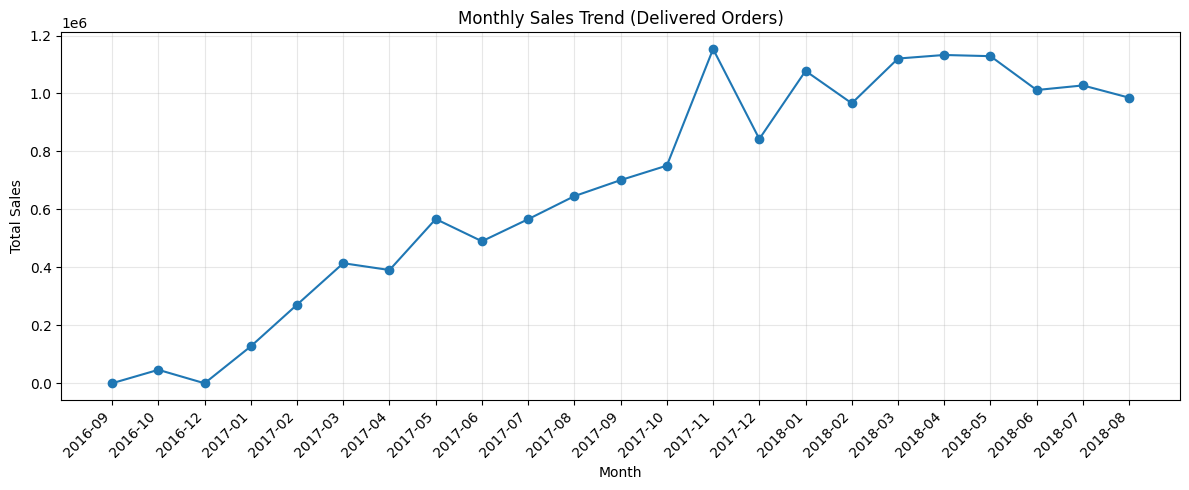

In [16]:
import matplotlib.pyplot as plt

monthly_sales_pd = monthly_sales.toPandas()
monthly_sales_pd['total_sales'] = monthly_sales_pd['total_sales'].astype(float)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales_pd['order_month'], monthly_sales_pd['total_sales'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Sales Trend (Delivered Orders)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

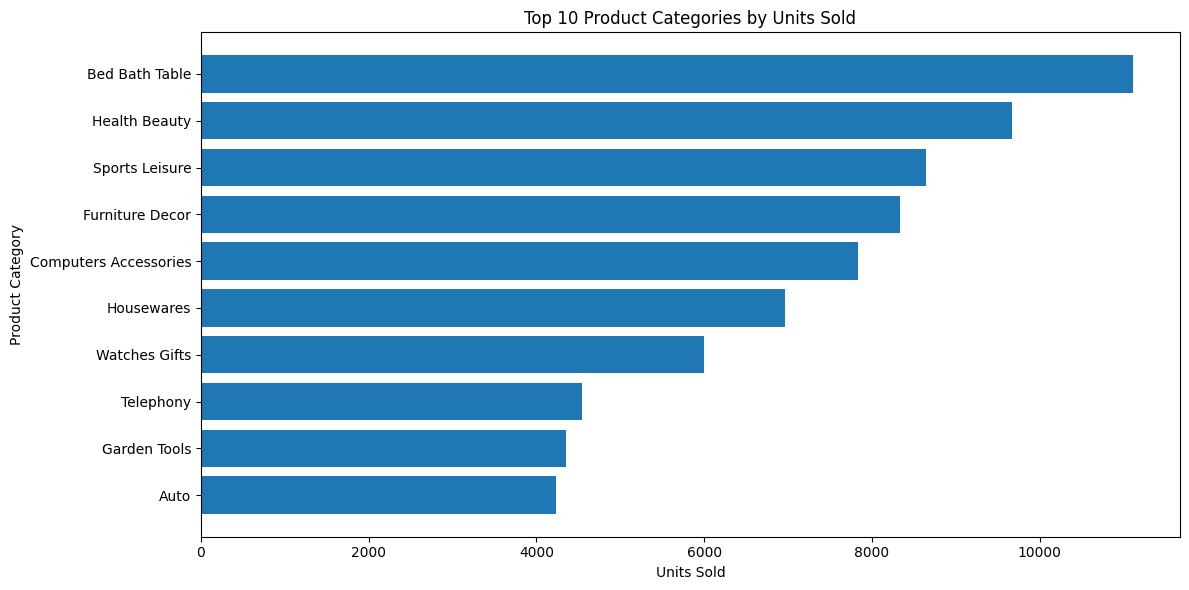

In [17]:
top_categories_pd = (
    top_selling_products
    .filter(F.col('product_category_name_english').isNotNull())
    .groupBy('product_category_name_english')
    .agg(
        F.sum('units_sold').alias('units_sold'),
        F.round(F.sum('product_revenue'), 2).alias('category_revenue')
    )
    .orderBy('units_sold', ascending=False)
    .limit(10)
    .toPandas()
)

top_categories_pd['category_label'] = (
    top_categories_pd['product_category_name_english']
    .str.replace('_', ' ', regex=False)
    .str.title()
)
top_categories_pd = top_categories_pd.sort_values('units_sold', ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(top_categories_pd['category_label'], top_categories_pd['units_sold'])
plt.title('Top 10 Product Categories by Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

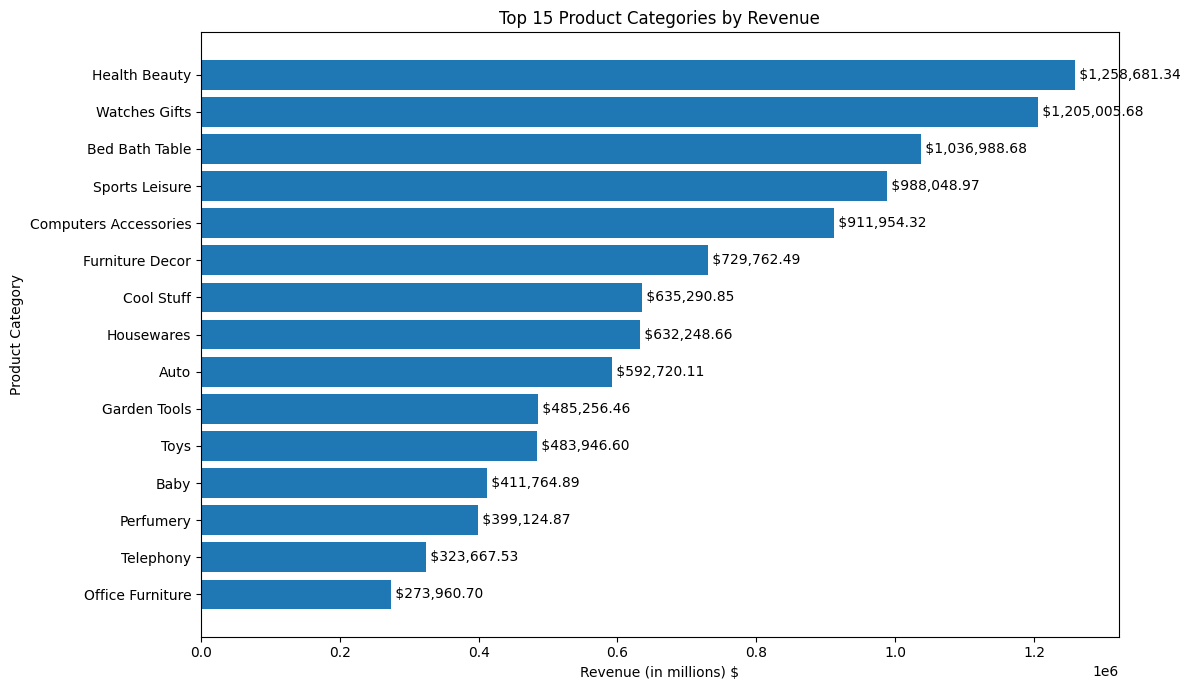

In [18]:
top_revenue_categories_pd = (
    top_selling_products
    .filter(F.col('product_category_name_english').isNotNull())
    .groupBy('product_category_name_english')
    .agg(F.round(F.sum('product_revenue'), 2).alias('category_revenue'))
    .orderBy('category_revenue', ascending=False)
    .limit(15)
    .toPandas()
)

top_revenue_categories_pd['category_revenue'] = top_revenue_categories_pd['category_revenue'].astype(float)
top_revenue_categories_pd['category_label'] = (
    top_revenue_categories_pd['product_category_name_english']
    .str.replace('_', ' ', regex=False)
    .str.title()
)
top_revenue_categories_pd = top_revenue_categories_pd.sort_values('category_revenue', ascending=True)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    top_revenue_categories_pd['category_label'],
    top_revenue_categories_pd['category_revenue']
 )

for bar, value in zip(bars, top_revenue_categories_pd['category_revenue']):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f' ${value:,.2f}',
        va='center',
        ha='left'
    )

plt.title('Top 15 Product Categories by Revenue')
plt.xlabel('Revenue (in millions) $')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

In [19]:
null_category_breakdown = (
    order_items
    .join(products, on='product_id', how='left')
    .join(category_translation, on='product_category_name', how='left')
    .withColumn(
        'null_category_reason',
        F.when(F.col('product_category_name').isNull(), 'missing source category')
         .when(F.col('product_category_name_english').isNull(), 'missing translation')
         .otherwise('mapped')
    )
    .groupBy('null_category_reason')
    .count()
    .orderBy('count', ascending=False)
)

null_category_breakdown.show(truncate=False)

+-----------------------+------+
|null_category_reason   |count |
+-----------------------+------+
|mapped                 |111023|
|missing source category|1603  |
|missing translation    |24    |
+-----------------------+------+

